In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cas n°2 : Dans le cas d'une crise ou d'une bulle spéculative une intervention extérieure peut modifier les prix.
# Agents rationnels, information parfaite, pas d'influence extérieure.

In [ ]:
def passage(matrice, etat):
    """ Définit aléatoirement le prochain état du marché """
    k = np.random.uniform()
    if k < matrice[etat][0]:
        return 0
    elif k < matrice[etat][0] + matrice[etat][1]:
        return 1
    else:
        return 2

def probapopulation(etat, vecteurpopulation):
    """ Modifie l'opinion de la population selon l'état """
    if etat == 0:
        return vecteurpopulation * 0.8
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        return np.array([min(1, e * 1.2) for e in vecteurpopulation])

def prop_investisseurs(etat, vecteurpopulation):
    """ Détermine les investisseurs actifs """
    if etat == 2:
        return np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        return np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        return np.array([e for e in vecteurpopulation if e < 0.4])
    return np.array([])

def calculer_indice(vecteurindice, vecteur_investisseurs, etat):
    """ Calcule l'indice global du marché """
    for i in range(len(vecteurindice)):
        res = 0
        n_inv = len(vecteur_investisseurs)
        if etat == 0:
            res = -np.sum(np.random.normal(0.001, 0.0001, n_inv))
        elif etat == 2:
            res = np.sum(np.random.normal(0.001, 0.0001, n_inv))
        elif etat == 1:
            res = np.sum(np.random.normal(0, 0.0001, n_inv))
        
        vecteurindice[i] = max(0.01, vecteurindice[i] + res)

    return np.mean(vecteurindice)

def probamatrice(matrice, etat, indice1, indice0, epsilon):
    """ Ajuste les probabilités de transition """
    variation = (indice1 - indice0) / max(indice0, 0.01)
    
    if abs(variation) < 0.0001:
        return matrice
    
    if indice1 <= 0.01:
        matrice[etat][0] = min(0.99, matrice[etat][0] + epsilon)
        matrice[etat][2] = max(0, matrice[etat][2] - epsilon)
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
        return matrice

    transfert = min(0.1, abs(epsilon * variation))
    if variation > 0:
        perte = min(matrice[etat][0], transfert)
        matrice[etat][0] -= perte
        matrice[etat][2] += perte
    else:
        perte = min(matrice[etat][2], transfert)
        matrice[etat][0] += perte
        matrice[etat][2] -= perte

    matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
    return matrice


def intervention(vecteurpopulation,vecteurprix,intensite,etat):

    if etat==0:
        vecteurprix=vecteurprix*(1+intensite)
        vecteurpopulation=vecteurpopulation*(1+intensite/2)
        
    elif etat==2:
        vecteurprix=vecteurprix*(1-intensite)
        vecteurpopulation=vecteurpopulation*(1-intensite/2)

    for i in range(len(vecteurpopulation)):
        if vecteurpopulation[i]>1:
            vecteurpopulation[i]=1
        if vecteurpopulation[i]<0:
            vecteurpopulation[i]=0

    return vecteurprix,vecteurpopulation



In [44]:
def fonction_cas2(matrice, etat, vecteurpopulation, vecteurprix, n, epsilon, intensite,duree, dureeaide):
    vecteur_indices = [1.0]
    matrice_pop = []
    vecteur_etats = [etat]
    tours_aide_restants = 0 
    compteur = 0 

    for i in range(n):
        nvetat = passage(matrice, vecteur_etats[i])
        
        if nvetat == vecteur_etats[i]:
            compteur += 1
        else:
            compteur = 1
        

        if compteur >= duree:
            tours_aide_restants = dureeaide 

        if tours_aide_restants > 0:
            vecteurprix, vecteurpopulation = intervention(vecteurpopulation, vecteurprix, intensite, nvetat)
            tours_aide_restants -= 1

        else:
            vecteurpopulation = probapopulation(nvetat, vecteurpopulation)

        matrice_pop.append(vecteurpopulation.copy())
        vecteur_investisseurs = prop_investisseurs(nvetat, vecteurpopulation)
        
        nouvel_indice = calculer_indice(vecteurprix, vecteur_investisseurs, nvetat)
        vecteur_indices.append(nouvel_indice)

        matrice = probamatrice(matrice, nvetat, vecteur_indices[i], vecteur_indices[i+1], epsilon)
        vecteur_etats.append(nvetat)
        
    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop

In [45]:
population = 100
titres2 = 10
res_cas2 = [1]
matrice_cas2 = [[0.9, 0.1 ,0], [0.05,0.9,0.05], [0,0.1,0.9]]  #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation1_cas2 = np.random.normal(0.5, 0.15, population) 
vecteurindices1_cas2 = np.array([np.random.uniform() for _ in range(titres2)])

vecteurpopulation2_cas2 = np.random.normal(0.5, 0.15, population) 
vecteurindices2_cas2 = np.array([np.random.uniform() for _ in range(titres2)])

vecteurpopulation3_cas2 = np.random.normal(0.5, 0.15, population) 
vecteurindices3_cas2 = np.array([np.random.uniform() for _ in range(titres2)])

In [46]:
etat2_cas2 = fonction_cas2(matrice=matrice_cas2, etat= 2, vecteurpopulation = vecteurpopulation1_cas2, vecteurprix=vecteurindices1_cas2, n=20, epsilon =0.01,intensite=10,duree=1, dureeaide = 5)
etat1_cas2 = fonction_cas2(matrice=matrice_cas2, etat= 1, vecteurpopulation = vecteurpopulation2_cas2, vecteurprix=vecteurindices2_cas2, n=20, epsilon =0.01,intensite=10,duree=1, dureeaide = 5)
etat0_cas2 = fonction_cas2(matrice=matrice_cas2, etat= 0, vecteurpopulation = vecteurpopulation3_cas2, vecteurprix=vecteurindices3_cas2, n=20, epsilon =0.01,intensite=10,duree=1, dureeaide = 5)

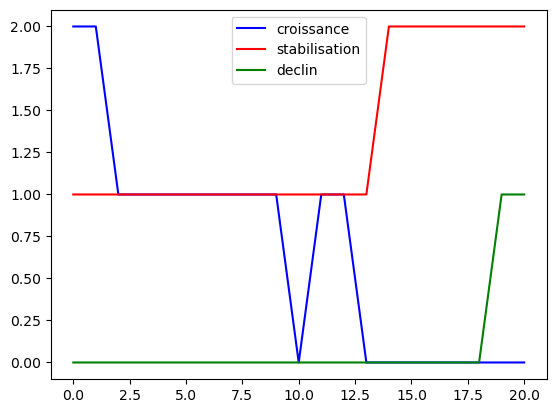

In [48]:
abscisse = np.arange(0, len(etat0_cas2[1]), 1)
plt.plot(abscisse, etat2_cas2[1], color = 'blue', label = "croissance")
plt.plot(abscisse, etat1_cas2[1], color = 'red', label = "stabilisation")
plt.plot(abscisse, etat0_cas2[1], color = 'green', label = "declin")
plt.legend()

In [25]:
etat0_cas2[0]

[[0.9, 0.1, 0],
 [0.05, 0.9, 0.05],
 [0.0324490558891413, 0.09999999999999998, 0.8675509441108588]]